# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

1. A model is linear when ist in the parameters. That means that x variables can be transformed however but the coefficients should be linear. Linear in the parameters.
2. When you one-hot encode n categories, you have to drop one, the omitted category. That makes it so the other dummy coefficients are interpreted relative to that category. Otherwise you get multicolinearity.
3. Yes, you can do the linear probability model but the values will be outside. Logistic regression is usaully better.
4. Overfitting could be told by big gaps between training and testing R^2, a big drop in R2 when you add variables, wrong coefficients or unnormal,
5. Multicolinearity happesn when the independent variation from 2sls barely exists and you cant seperate. 2sls creates that variation.
6. You can transform the x varibles so things like ln(x),x^2.
7. Intercept is y when all x is equal to 0. Slope is what an increasei n x is associatied with the change in y, and the dummy coefficient is the difference in y relative to the omitted category.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

                Price  Review Scores Rating
Neighbourhood                              
Bronx           75.28                 91.65
Brooklyn       127.75                 92.36
Manhattan      183.66                 91.80
Queens          96.86                 91.55
Staten Island  146.17                 90.84


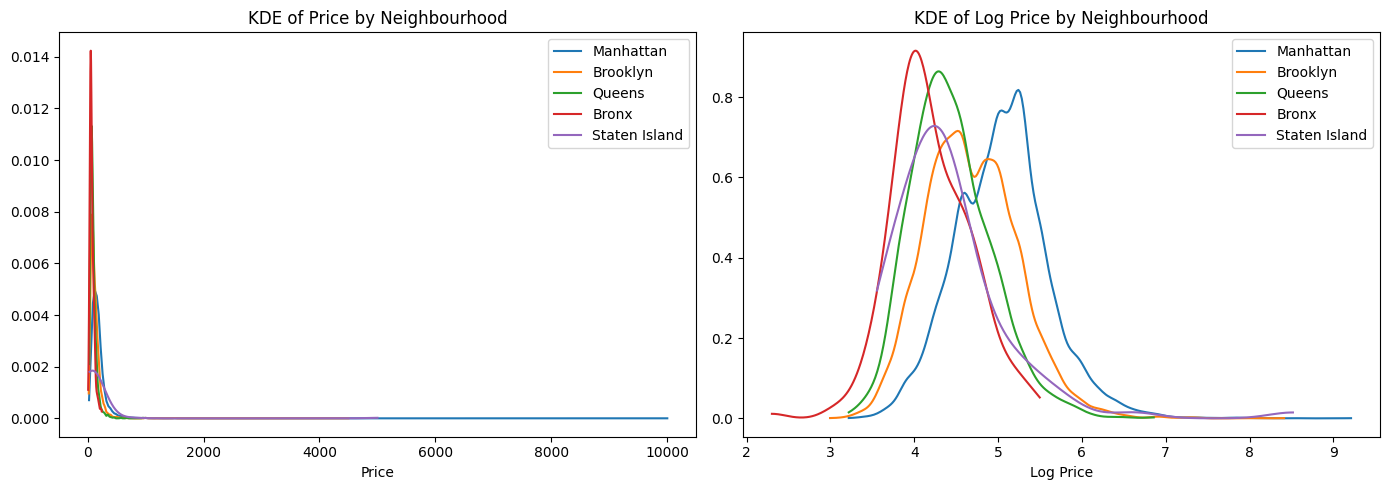

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        21:19:11   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Bronx            75.2765      9.868      7.628

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import statsmodels.api as sm

df = pd.read_csv('/content/Q1_clean.csv')
df = df.rename(columns={'Neighbourhood ': 'Neighbourhood'})

print(df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
neighbourhoods = df['Neighbourhood'].unique()

for n in neighbourhoods:
    subset = df[df['Neighbourhood'] == n]['Price'].dropna()
    kde = gaussian_kde(subset)
    x = np.linspace(subset.min(), subset.max(), 300)
    axes[0].plot(x, kde(x), label=n)

axes[0].set_title('KDE of Price by Neighbourhood')
axes[0].set_xlabel('Price')
axes[0].legend()

for n in neighbourhoods:
    subset = np.log(df[df['Neighbourhood'] == n]['Price'].dropna())
    kde = gaussian_kde(subset)
    x = np.linspace(subset.min(), subset.max(), 300)
    axes[1].plot(x, kde(x), label=n)

axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[1].set_xlabel('Log Price')
axes[1].legend()

plt.tight_layout()
plt.show()

dummies_no_drop = pd.get_dummies(df['Neighbourhood'], dtype=int)
model1 = sm.OLS(df['Price'], dummies_no_drop).fit()
print(model1.summary())
print(pd.DataFrame({'Coefficient': model1.params, 'Group Mean': df.groupby('Neighbourhood')['Price'].mean()}).round(2))
#The coefficients are pretty much identical down to the two decimal points. When you regress a continuos variable, the coefficients are the means of the outcome.
dummies_drop = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)
dummies_drop = sm.add_constant(dummies_drop)
model2 = sm.OLS(df['Price'], dummies_drop).fit()
print(model2.summary())
#The intercept is the mean price of the bronx, the dropped category. To get the coefficients, subtract the 75.28 from the Bronx.
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

df_clean = df[['Price', 'Review Scores Rating', 'Neighbourhood']].dropna()

X = pd.get_dummies(df_clean[['Review Scores Rating', 'Neighbourhood']], drop_first=True, dtype=int)
X = sm.add_constant(X)
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model3 = sm.OLS(y_train, X_train).fit()
print(model3.summary())

y_pred = model3.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - y_test.mean())**2)
r2 = 1 - ss_res/ss_tot
print(f"\nTest R2: {r2:.4f}")
print(f"Test RMSE: {rmse:.2f}")
print(df.groupby('Property Type')['Price'].mean().sort_values(ascending=False).head(10))
#1.2119 increase in price. The model only explains 5% of the variation which is bad.
#Condominium is the most expensive.
df2 = df[['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type']].dropna()
X2 = sm.add_constant(pd.get_dummies(df2.drop(columns='Price'), drop_first=True, dtype=int))
y2 = df2['Price']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)
model4 = sm.OLS(y_train2, X_train2).fit()
y_pred2 = model4.predict(X_test2)
print(model4.summary())
print(f"Test R2: {1 - np.sum((y_test2-y_pred2)**2)/np.sum((y_test2-y_test2.mean())**2):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test2, y_pred2)):.2f}")
#Basically didnt change for the coefficient. The imporvment was small for the variation. The most expensive was the loft.

#6. The coefficient barely changed. So that means the review scores and property type are largely uncorrelated. Controlling tht type didnt change the ratings on price.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

count    9.660000e+02
mean     7.268965e+05
std      3.406196e+05
min      1.880000e+05
25%      4.727500e+05
50%      6.625000e+05
75%      8.747500e+05
max      1.978000e+06
Name: Price, dtype: float64
               count       mean       std        min        25%        50%  \
Make                                                                         
MG Motors       27.0  1830333.0  110938.0  1589000.0  1767000.0  1822000.0   
Kia              8.0  1614750.0  119057.0  1369000.0  1579000.0  1628500.0   
Jeep             4.0  1499500.0  152513.0  1290000.0  1447500.0  1529500.0   
Mahindra        18.0  1100167.0  175549.0   796000.0  1037000.0  1094500.0   
Tata            22.0  1007727.0  521201.0   188000.0   776750.0   863500.0   
Nissan           4.0   884250.0  289560.0   475000.0   782500.0   978000.0   
Toyota          50.0   800340.0  246690.0   368000.0   526250.0   894000.0   
Honda           73.0   798973.0  266509.0   316000.0   581000.0   785000.0   
Ford            

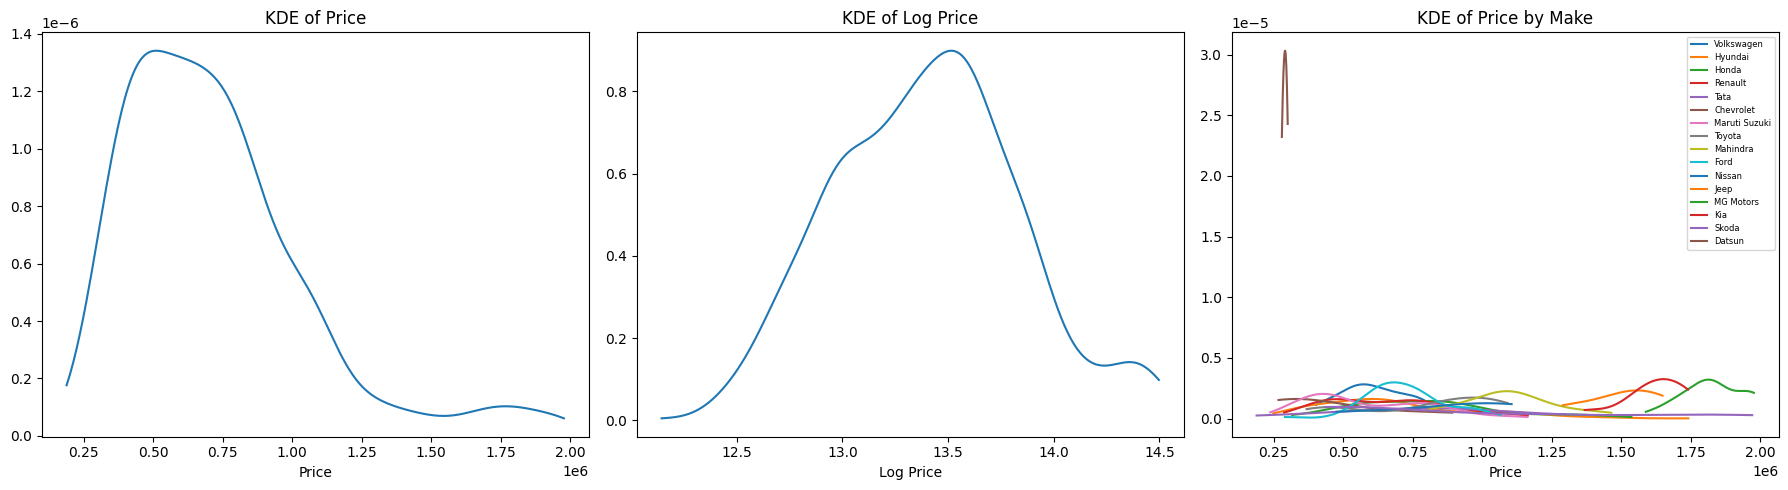

(772, 15) (194, 15)
Model 1 - Numeric only
Train R2: 0.4256  RMSE: 0.34
Test  R2: 0.3576  RMSE: 0.33

Model 2 - Categorical only
Train R2: 0.6410  RMSE: 0.26
Test  R2: 0.5488  RMSE: 0.28

Model 3 - Combined
Train R2: 0.8235  RMSE: 0.19
Test  R2: 0.7731  RMSE: 0.20
Degree 1 | Train R2: 0.4256 RMSE: 0.335 | Test R2: 0.3576 RMSE: 0.333
Degree 2 | Train R2: 0.4607 RMSE: 0.325 | Test R2: 0.3745 RMSE: 0.329
Degree 3 | Train R2: 0.4751 RMSE: 0.320 | Test R2: 0.3582 RMSE: 0.333
Degree 4 | Train R2: 0.4863 RMSE: 0.317 | Test R2: 0.2790 RMSE: 0.353
Degree 5 | Train R2: 0.5001 RMSE: 0.313 | Test R2: -8129.4461 RMSE: 37.490


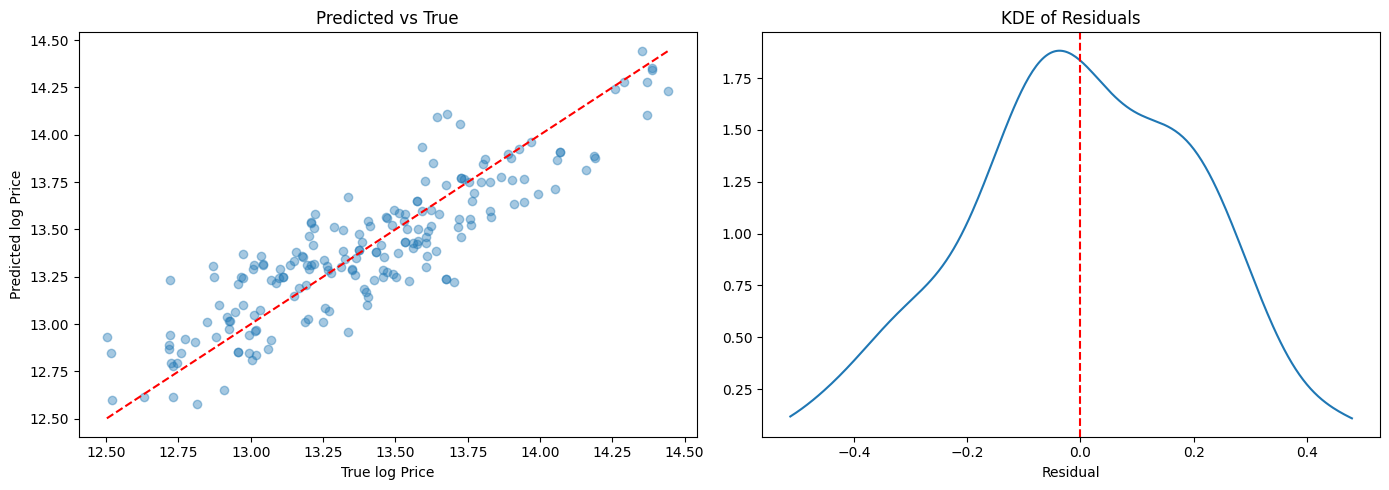

Residual mean: 0.0019
Residual std:  0.1986


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

df = pd.read_csv('cars_hw.csv', index_col=0)

df['log_Price'] = np.log(df['Price'])
df['log_Mileage'] = np.log(df['Mileage_Run'])
df['Age'] = 2024 - df['Make_Year']
df = df[df['Price'] < df['Price'].quantile(0.99)]
df['First_Owner'] = (df['No_of_Owners'] == '1st').astype(int)
df['Fuel_Type'] = df['Fuel_Type'].str.lower().str.strip()
df['Transmission_Type'] = df['Transmission_Type'].str.lower().str.strip()

print(df['Price'].describe())
print(df.groupby('Make')['Price'].describe().sort_values('mean', ascending=False).round(0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for vals, ax, title, col in [
    ([df['Price']], axes[0], 'KDE of Price', 'Price'),
    ([df['log_Price']], axes[1], 'KDE of Log Price', 'Log Price'),
    (df['Make'].unique(), axes[2], 'KDE of Price by Make', 'Price')
]:
    if title == 'KDE of Price by Make':
        for make in vals:
            subset = df[df['Make'] == make]['Price'].dropna()
            kde = gaussian_kde(subset)
            x = np.linspace(subset.min(), subset.max(), 300)
            ax.plot(x, kde(x), label=make)
        ax.legend(fontsize=6)
    else:
        subset = vals[0].dropna()
        kde = gaussian_kde(subset)
        x = np.linspace(subset.min(), subset.max(), 300)
        ax.plot(x, kde(x))
    ax.set_title(title)
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()
#MG motors is most expsneive, then Kia, Jeep etc. In general, the prices are around the 750k mark. But the distribution is right skewed.
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)
print(train.shape, test.shape)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def get_metrics(model, X_tr, y_tr, X_te, y_te):
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)
    print(f"Train R2: {model.score(X_tr, y_tr):.4f}  RMSE: {np.sqrt(mean_squared_error(y_tr, tr_pred)):.2f}")
    print(f"Test  R2: {model.score(X_te, y_te):.4f}  RMSE: {np.sqrt(mean_squared_error(y_te, te_pred)):.2f}")

numeric_cols = ['Age', 'log_Mileage', 'Seating_Capacity', 'First_Owner']
cat_cols = ['Make', 'Body_Type', 'Fuel_Type', 'Transmission_Type', 'Color']

X_num = df[numeric_cols]
X_cat = pd.get_dummies(df[cat_cols], drop_first=True, dtype=int)
X_all = pd.concat([X_num, X_cat], axis=1)
y = df['log_Price']

X_num_tr, X_num_te = X_num.loc[train.index], X_num.loc[test.index]
X_cat_tr, X_cat_te = X_cat.loc[train.index], X_cat.loc[test.index]
X_all_tr, X_all_te = X_all.loc[train.index], X_all.loc[test.index]
y_tr, y_te = y.loc[train.index], y.loc[test.index]

m1 = LinearRegression().fit(X_num_tr, y_tr)
print("Model 1 - Numeric only")
get_metrics(m1, X_num_tr, y_tr, X_num_te, y_te)

m2 = LinearRegression().fit(X_cat_tr, y_tr)
print("\nModel 2 - Categorical only")
get_metrics(m2, X_cat_tr, y_tr, X_cat_te, y_te)

m3 = LinearRegression().fit(X_all_tr, y_tr)
print("\nModel 3 - Combined")
get_metrics(m3, X_all_tr, y_tr, X_all_te, y_te)
#Model 2 outperforms Model 1 on the test, higher R2. Explains more variation
#The joint model performs much better. It has a R2 of .77. Large gain there.
from sklearn.preprocessing import PolynomialFeatures

for degree in range(1, 6):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly_tr = poly.fit_transform(X_num_tr)
    X_poly_te = poly.transform(X_num_te)
    m = LinearRegression().fit(X_poly_tr, y_tr)
    tr_rmse = np.sqrt(mean_squared_error(y_tr, m.predict(X_poly_tr)))
    te_rmse = np.sqrt(mean_squared_error(y_te, m.predict(X_poly_te)))
    print(f"Degree {degree} | Train R2: {m.score(X_poly_tr, y_tr):.4f} RMSE: {tr_rmse:.3f} | Test R2: {m.score(X_poly_te, y_te):.4f} RMSE: {te_rmse:.3f}")
#R2 improves on training and RMSE falls. On test, it improves til ldegree 4 and then falsl after. Degree 5 is when it goes negative (overfitting)
#Best model is Degree 4. It is worse than the model 3 from the last part though.
y_pred3 = m3.predict(X_all_te)
residuals = y_te - y_pred3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_te, y_pred3, alpha=0.4)
axes[0].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
axes[0].set_xlabel('True log Price')
axes[0].set_ylabel('Predicted log Price')
axes[0].set_title('Predicted vs True')

kde = gaussian_kde(residuals)
x = np.linspace(residuals.min(), residuals.max(), 300)
axes[1].plot(x, kde(x))
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title('KDE of Residuals')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std:  {residuals.std():.4f}")
#yes, they line up reasonably well and follow the red line.
#Mean is pretty close Its a little left skewed but looks pretty approximiate

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.